In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme (style = "whitegrid")
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
dfbankloan = pd.read_excel('/content/drive/MyDrive/Lab-AI/Bankloan descargable.xls', sheet_name=0)
dfTrainingData = pd.read_excel('/content/drive/MyDrive/Lab-AI/Bankloan descargable.xls', sheet_name=1)

In [3]:
print("Dimensiones de los datos para entrenamiento: ", dfbankloan.shape)
print("Dimensiones de los datos para entrenamiento: ", dfTrainingData.shape)

Dimensiones de los datos para entrenamiento:  (1200, 11)
Dimensiones de los datos para entrenamiento:  (300, 10)


In [4]:
dfbankloan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer     1200 non-null   int64  
 1   Age          1199 non-null   float64
 2   Employ       1200 non-null   int64  
 3   Address      1199 non-null   float64
 4   Income       1198 non-null   float64
 5   Debtinc      1199 non-null   float64
 6   Creddebt     1200 non-null   float64
 7   OthDebt      1200 non-null   float64
 8   Education    1199 non-null   object 
 9   Nationality  1200 non-null   object 
 10  Default      1200 non-null   object 
dtypes: float64(6), int64(2), object(3)
memory usage: 103.3+ KB


In [5]:
dfTrainingData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   customer     300 non-null    int64  
 1   Age          300 non-null    int64  
 2   Employ       299 non-null    float64
 3   Address      299 non-null    float64
 4   Income       299 non-null    float64
 5   Debtinc      299 non-null    float64
 6   Creddebt     300 non-null    float64
 7   OthDebt      300 non-null    float64
 8   Education    299 non-null    object 
 9   Nationality  299 non-null    object 
dtypes: float64(6), int64(2), object(2)
memory usage: 23.6+ KB


In [89]:
dfbankloan[dfbankloan['Age'] > 100]

,customer,Age,Employ,Address,Income,Debtinc,Creddebt,OthDebt,Education,Nationality,Default


In [85]:
dfbankloan = dfbankloan[dfbankloan['Age'] <= 100].copy()

In [86]:
dfbankloan.head()

,customer,Age,Employ,Address,Income,Debtinc,Creddebt,OthDebt,Education,Nationality,Default
0,10012,28.0,7,2.0,44.0,17.7,2.99,4.80,Med,N,N
1,10017,64.0,34,17.0,116.0,14.7,5.05,12.00,Posg,N,N
2,10030,40.0,20,12.0,61.0,4.8,1.04,1.89,Bas,N,N
3,10039,30.0,11,3.0,27.0,34.5,1.75,7.56,Bas,N,N
4,10069,25.0,2,2.0,30.0,22.4,0.76,5.96,Bas,N,S


In [115]:
print(dfbankloan['Nationality'].value_counts())

Nationality
N    1084
Name: count, dtype: int64


In [7]:
dfTrainingData.head()

,customer,Age,Employ,Address,Income,Debtinc,Creddebt,OthDebt,Education,Nationality
0,375011,48,2.0,6.0,52.0,13.1,1.52,5.29,Posg,N
1,375014,40,2.0,6.0,30.0,3.0,0.05,0.85,Bas,N
2,375038,26,2.0,2.0,23.0,2.5,0.03,0.54,Bas,N
3,375102,30,0.0,6.0,25.0,5.7,0.48,0.94,Bas,N
4,375106,39,0.0,4.0,36.0,7.5,0.87,1.83,Med,N


In [32]:
dfbankloan.describe()

,customer,Age,Employ,Address,Income,Debtinc,Creddebt,OthDebt
count,1198.000000,1198.000000,1198.000000,1197.000000,1196.000000,1197.000000,1198.000000,1198.000000
mean,221687.027546,34.348080,7.064274,6.385129,60.044314,10.196909,2.004232,4.028180
std,131854.229568,13.246265,9.178998,6.099335,67.853279,6.862937,2.951714,5.622888
min,10012.000000,18.000000,0.000000,0.000000,-149.000000,0.100000,0.010000,0.010000
25%,95038.000000,24.000000,0.000000,2.000000,28.000000,4.900000,0.432500,1.142500
50%,295018.500000,31.000000,4.000000,5.000000,40.000000,8.800000,1.050000,2.325000
75%,354607.000000,42.000000,10.000000,10.000000,65.000000,13.900000,2.340000,4.747500
max,372571.000000,79.000000,63.000000,34.000000,1079.000000,40.700000,35.970000,63.470000


La edad max es 1970, lo cual no es coherente con el resto de valores y la media.

Hay un valor de la columna income que tiene un valor de -149 lo cual no tiene sentido.

El promedio y la desviacion estandar de la columna 'customer' no tiene sentido.

In [33]:
dfbankloan[dfbankloan['Income'] < 0]

,customer,Age,Employ,Address,Income,Debtinc,Creddebt,OthDebt,Education,Nationality,Default
71,11860,66.0,40,17.0,-149.0,13.1,7.79,11.73,Bas,N,N


In [34]:
dfbankloan = dfbankloan[dfbankloan['Income'] >= 0]

In [35]:
# La fila con Income negative ya no esta

dfbankloan.describe()

,customer,Age,Employ,Address,Income,Debtinc,Creddebt,OthDebt
count,1195.000000,1195.000000,1195.000000,1194.000000,1195.000000,1194.000000,1195.000000,1195.000000
mean,222172.086192,34.317155,7.035983,6.378559,60.219247,10.201759,2.000628,4.025431
std,131657.838360,13.230491,9.140695,6.098994,67.611342,6.867369,2.950327,5.624416
min,10012.000000,18.000000,0.000000,0.000000,12.000000,0.100000,0.010000,0.010000
25%,95102.000000,24.000000,0.000000,2.000000,28.000000,4.925000,0.430000,1.145000
50%,295035.000000,31.000000,4.000000,5.000000,40.000000,8.800000,1.050000,2.320000
75%,360112.000000,42.000000,10.000000,9.750000,65.000000,13.900000,2.340000,4.745000
max,372571.000000,79.000000,63.000000,34.000000,1079.000000,40.700000,35.970000,63.470000


In [52]:
# Calculando IQR

Q1 = dfbankloan['Income'].quantile(0.25)
Q3 = dfbankloan['Income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR # Corrected: Standard upper bound for outliers is Q3 + 1.5 * IQR

print(f"Original DataFrame shape: {dfbankloan.shape[0]}") # Use shape[0] for row count

# Elimando outliers
# Keep rows where 'Income' is within the calculated bounds
dfbankloan = dfbankloan[((dfbankloan['Income'] >= lower_bound) & (dfbankloan['Income'] <= upper_bound))]

print(f"DataFrame shape after outlier removal: {dfbankloan.shape[0]}") # Use shape[0] for row count

Original DataFrame shape: 1195
DataFrame shape after outlier removal: 1084


In [9]:
dfTrainingData.describe()

,customer,Age,Employ,Address,Income,Debtinc,Creddebt,OthDebt
count,300.000000,300.000000,299.000000,299.000000,299.000000,299.000000,300.000000,300.000000
mean,403228.476667,33.453333,6.505017,6.016722,57.117057,8.876923,1.664567,3.124367
std,34437.230134,12.754217,8.162515,5.854189,65.637936,5.763223,3.059225,3.916910
min,375011.000000,18.000000,0.000000,0.000000,13.000000,0.000000,0.000000,0.000000
25%,377670.000000,24.000000,0.000000,2.000000,25.500000,4.400000,0.390000,1.037500
50%,381267.500000,30.000000,4.000000,4.000000,38.000000,7.700000,0.845000,1.980000
75%,450870.000000,39.000000,9.500000,9.000000,60.500000,12.250000,1.597500,3.732500
max,453777.000000,77.000000,44.000000,33.000000,533.000000,38.800000,35.520000,40.700000


In [101]:
bank_missing_values = dfbankloan.isnull().sum()
print(bank_missing_values)

customer       0
Age            0
Employ         0
Address        1
Income         0
Debtinc        0
Creddebt       0
OthDebt        0
Education      1
Nationality    0
Default        0
dtype: int64


In [36]:
# Imputar los datos de la columna Age con la media de los datos

dfTrainingData['Age'] = dfTrainingData['Age'].fillna(dfTrainingData['Age'].median())
training_missing_values = dfTrainingData.isnull().sum()
print("Missing values en la columna Age: ", training_missing_values['Age'])

Missing values en la columna Age:  0


In [37]:
# Imputar los datos de la columna Income con la media de los datos

dfTrainingData['Income'] = dfTrainingData['Income'].fillna(dfTrainingData['Income'].median())
print("Missing values en la columna Income: ", training_missing_values['Income'])

Missing values en la columna Income:  0


In [13]:
#no_na_dfbankloan = dfbankloan.loc[dfbankloan['Income'] < 0, ['Income']] = np.nan
#print(no_na_dfbankloan)
#
#no_na_dfTrainingData = dfTrainingData.loc[dfTrainingData['Income'] < 0, ['Income']] = np.nan

In [62]:
dfbankloan['Default'].map({'S': 'Si', 'N': 'No'}).value_counts()

,count
Default,
No,665
Si,419


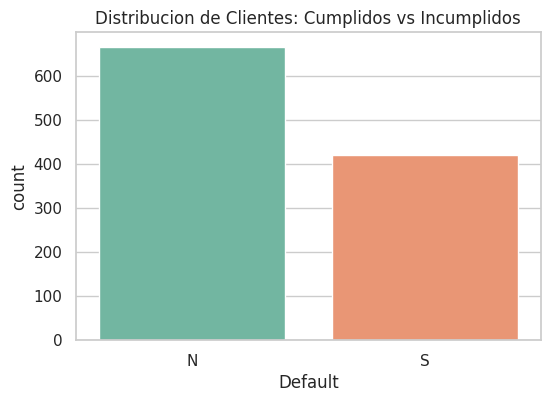

In [114]:
# Visualizar cuantos clientes han incumplido su prestamo

plt.figure(figsize=(6, 4))
sns.countplot(data=dfbankloan, x='Default', palette='Set2')
plt.title('Distribucion de Clientes: Cumplidos vs Incumplidos')
plt.show()

In [113]:
# Ver el porcentaje exacto
print(dfbankloan['Default'].value_counts(normalize=True) * 100)

Default
N    61.346863
S    38.653137
Name: proportion, dtype: float64


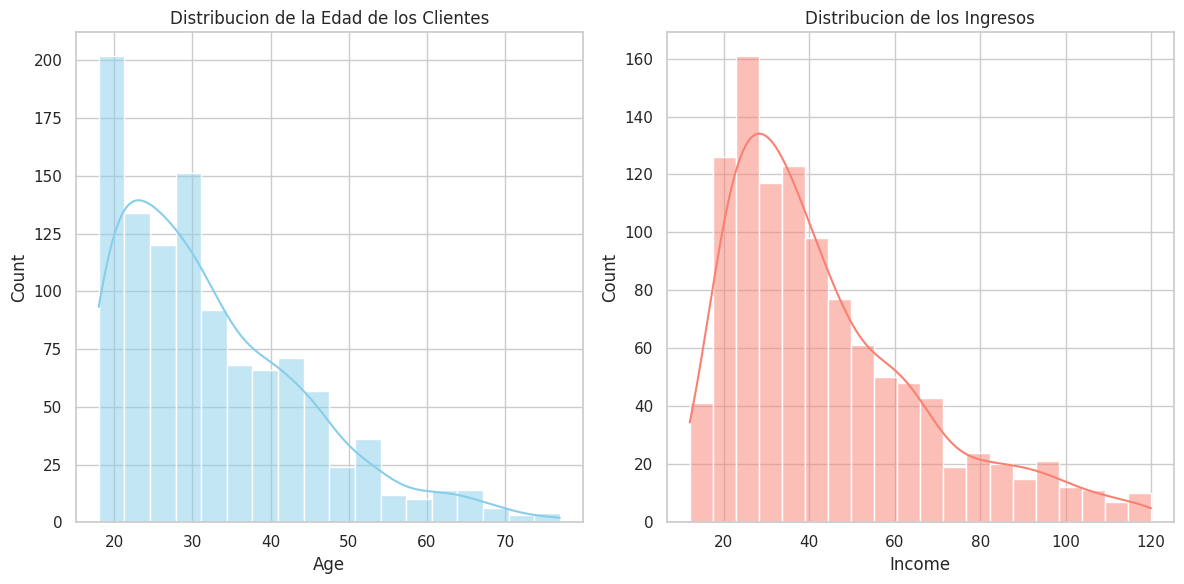

In [54]:
# Como se distribuyen los ingresos (Income) o la edad (Age) de los clientes?
from matplotlib import axes

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.histplot(dfbankloan['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribucion de la Edad de los Clientes')

sns.histplot(dfbankloan['Income'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribucion de los Ingresos')

plt.tight_layout()
plt.show()

In [106]:
default = dfbankloan[dfbankloan['Default'] == 'S']
no_default = dfbankloan[dfbankloan['Default'] == 'N']

default = default.drop(['Default', 'Nationality', 'Education'], axis=1)
no_default = no_default.drop(['Default', 'Nationality', 'Education'], axis=1)

print(f"\nPrinting first 5 rows of clients who defaulted: \n{default.head()}" )
print(f"\nPrinting first 5 rows of clients who didnt default: \n {no_default.head()}")
print()
display(default.corr())


Printing first 5 rows of clients who defaulted: 
    customer   Age  Employ  Address  Income  Debtinc  Creddebt  OthDebt
4      10069  25.0       2      2.0    30.0     22.4      0.76     5.96
6      10096  26.0       2      4.0    38.0     11.9      0.95     3.57
11     10169  30.0       4      3.0    39.0     10.6      2.39     1.74
15     10234  18.0       0      0.0    15.0      7.4      0.83     0.28
16     10351  18.0       0      0.0    56.0     15.7      1.84     6.95

Printing first 5 rows of clients who didnt default: 
    customer   Age  Employ  Address  Income  Debtinc  Creddebt  OthDebt
0     10012  28.0       7      2.0    44.0     17.7      2.99     4.80
1     10017  64.0      34     17.0   116.0     14.7      5.05    12.00
2     10030  40.0      20     12.0    61.0      4.8      1.04     1.89
3     10039  30.0      11      3.0    27.0     34.5      1.75     7.56
7     10128  25.0       4      2.0    30.0     14.4      1.05     3.27



,customer,Age,Employ,Address,Income,Debtinc,Creddebt,OthDebt
customer,1.000000,-0.040304,-0.029744,-0.032126,-0.023590,0.066677,0.007190,0.029325
Age,-0.040304,1.000000,0.607993,0.929663,0.508088,0.239921,0.411934,0.393632
Employ,-0.029744,0.607993,1.000000,0.520362,0.457307,0.322510,0.513657,0.448160
Address,-0.032126,0.929663,0.520362,1.000000,0.450092,0.227296,0.378302,0.333378
Income,-0.023590,0.508088,0.457307,0.450092,1.000000,0.135707,0.641471,0.611786
Debtinc,0.066677,0.239921,0.322510,0.227296,0.135707,1.000000,0.559784,0.683811
Creddebt,0.007190,0.411934,0.513657,0.378302,0.641471,0.559784,1.000000,0.544922
OthDebt,0.029325,0.393632,0.448160,0.333378,0.611786,0.683811,0.544922,1.000000


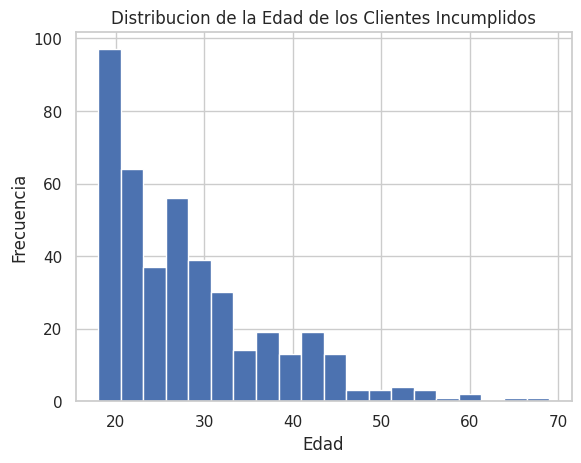

In [97]:
plt.hist(default['Age'], bins=20)
plt.title('Distribucion de la Edad de los Clientes Incumplidos')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

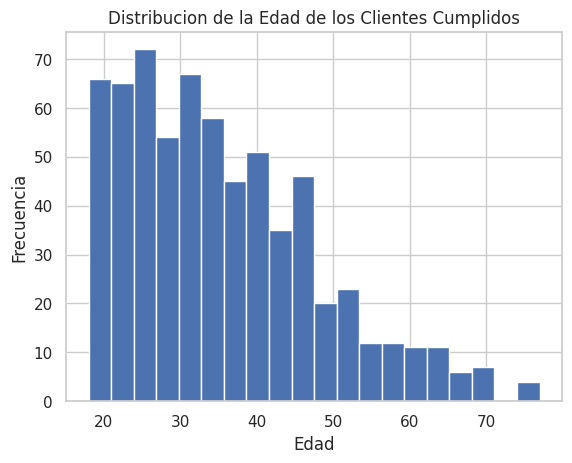

In [96]:
plt.hist(no_default['Age'], bins=20)
plt.title('Distribucion de la Edad de los Clientes Cumplidos')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

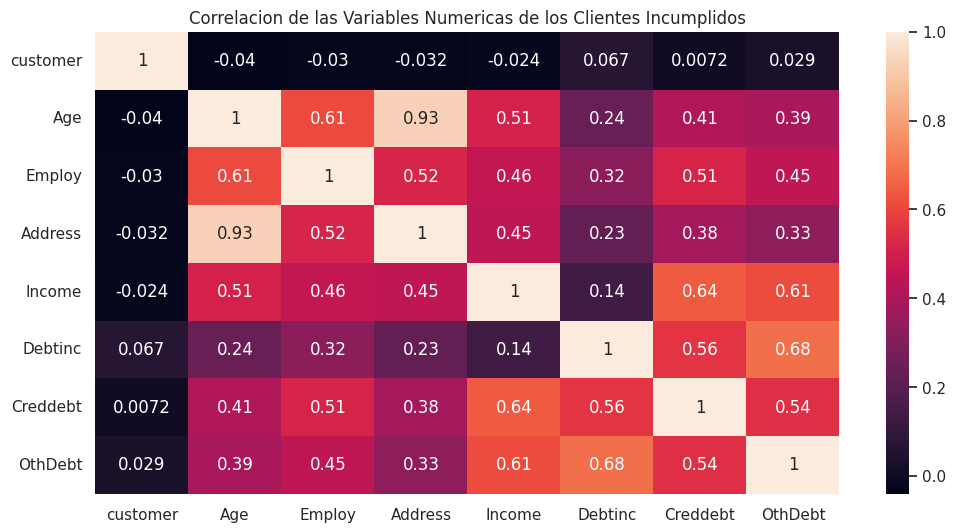

In [109]:
sns.set_style("whitegrid")
sns.color_palette("flare", as_cmap=True)
plt.figure(figsize=(12, 6))

plt.title('Correlacion de las Variables Numericas de los Clientes Incumplidos')
sns.heatmap(default.corr(), annot=True)
plt.show()

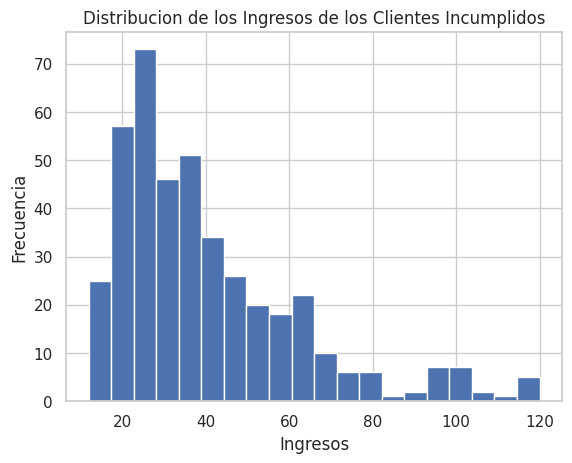

In [111]:
plt.hist(default['Income'], bins=20)
plt.title('Distribucion de los Ingresos de los Clientes Incumplidos')
plt.xlabel('Ingresos')
plt.ylabel('Frecuencia')
plt.show()

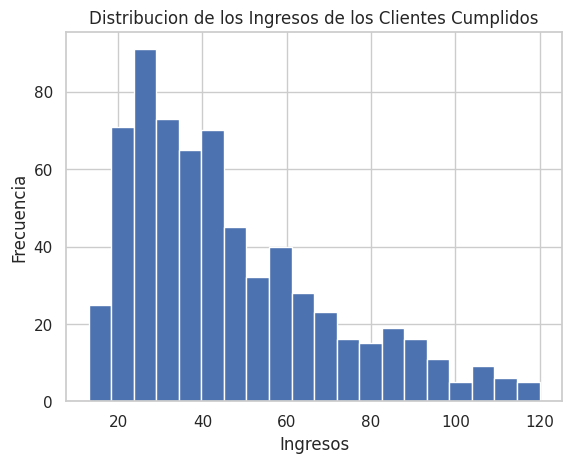

In [112]:
plt.hist(no_default['Income'], bins=20)
plt.title('Distribucion de los Ingresos de los Clientes Cumplidos')
plt.xlabel('Ingresos')
plt.ylabel('Frecuencia')
plt.show()

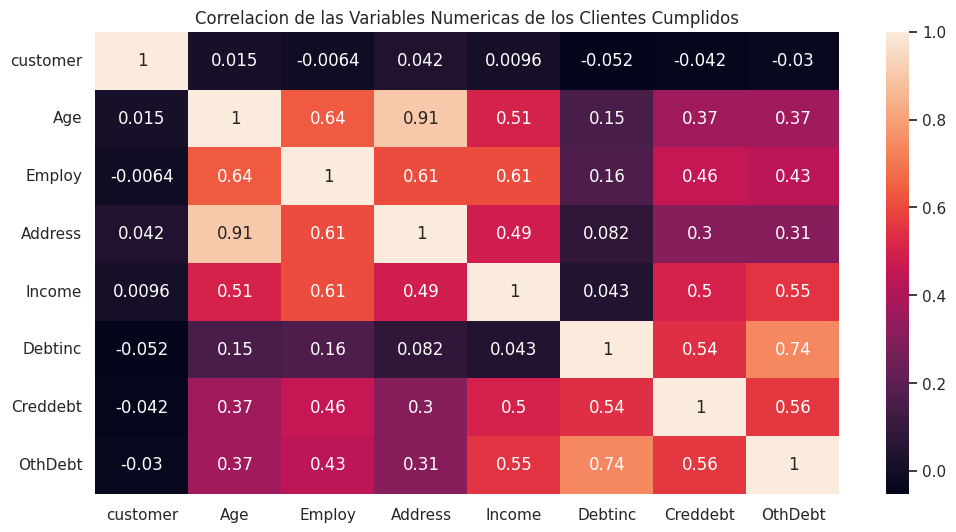

In [110]:
sns.set_style("whitegrid")
sns.color_palette("flare", as_cmap=True)
plt.figure(figsize=(12, 6))

plt.title('Correlacion de las Variables Numericas de los Clientes Cumplidos')
sns.heatmap(no_default.corr(), annot=True)
plt.show()

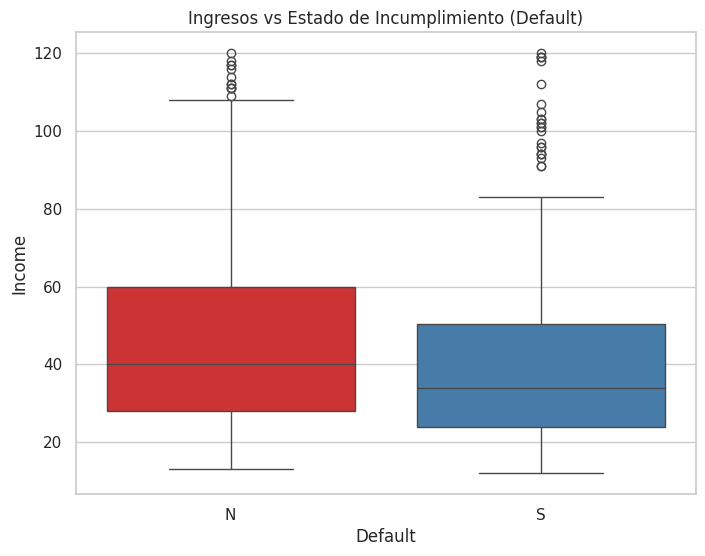

In [116]:
# Los clientes con menores ingresos tienen a incumplir mas?

plt.figure(figsize=(8, 6))
sns.boxplot(data=dfbankloan, x='Default', y='Income', palette='Set1')
plt.title('Ingresos vs Estado de Incumplimiento (Default)')
#plt.yscale('log') # Escala logaritmica debido a valores extremos
plt.show()

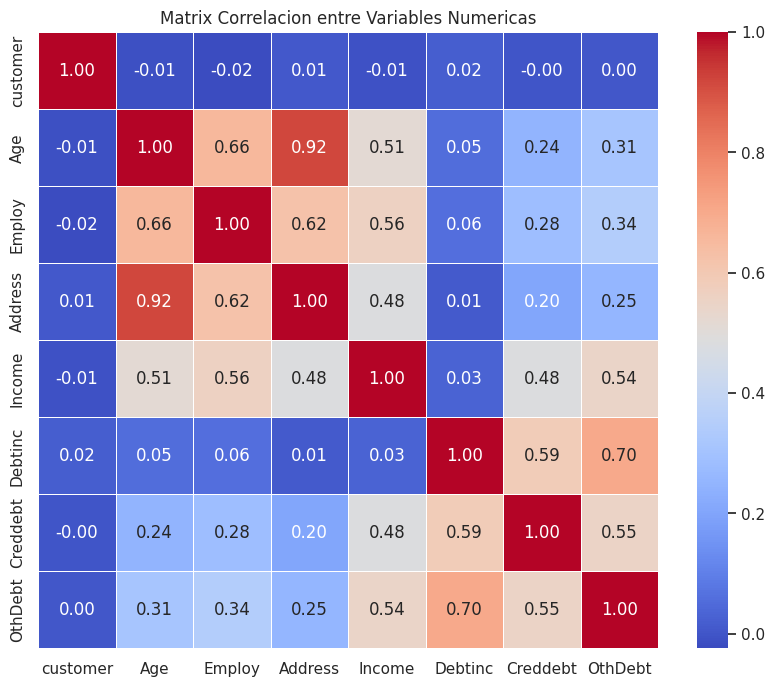

In [117]:
# Para ver como se relacionan las variables numericas entre si (por ejemplo, Deuda vs Edad), calculamos la correlacion de Pearson.

plt.figure(figsize=(10, 8))

# Selecionamos solo las columnas numericas para la corelaccion
numeric_cols = dfbankloan.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrix Correlacion entre Variables Numericas')
plt.show()



**1. Observa el mapa de calor (heatmap). Cuales variables tienen correlacion positiva mas fuerte?** - Las variables que mas estan correlacionadas positivamente entre si son (Age)<>(Address) y (Debtinc)<>(OthDebt)

**2. Tienen sentido logico que esas dos caracteristicas esten altamente conectadas?** - Tiene sentido que la variable (Age) y (Address) esten correlacionadas positivamente, ya que es posible que un grupo demografico (rango de edad) vivan en la misma zona?

# Preguntas

1. **Que perfil demografico es mas propenso a incumplir (Default = S)?** - Los jovenes. Rango de edad entre 20-30 anos
2. **Hubo valores atipicos (outliers) que requieran tratamiento antes de entrenar una red neuronal o un arbol de decision?** - Si, en la columna de "Income" y "Age"
3. **Que variables parecen ser las mas importantes para predecir el riesgo?** - La edad.



